In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")

# Reuse constants from the OUTL notebook
CARRYING_RATE = 0.25
ORDERING_COST = 50.0
REVIEW_PERIOD = 7
ANNUAL_DAYS   = 365
MARGIN        = 0.40

# Sensitivity grids
MAPE_VALUES        = np.arange(3, 16, 1)         # 3% → 15% per §3.9
LEAD_TIMES         = [7, 10, 14, 21]
SERVICE_LEVELS     = {0.90: 1.2816, 0.95: 1.6449, 0.99: 2.3263}
STOCKOUT_MULTS     = [0.4, 1.0, 2.0]              # lost margin, full cost, with reputation

# Load aggregated series stats from OUTL notebook
features = pd.read_parquet("../data/processed/subsample_features.parquet")
prices = features.groupby("id", as_index=False)["sell_price"].mean().rename(
    columns={"sell_price": "avg_price"})
prices["unit_cost"] = prices["avg_price"] * (1 - MARGIN)

# Use ensemble test predictions to anchor demand level + true demand stats
ensemble = pd.read_parquet("../artifacts/ensemble_test_predictions.parquet")
demand = ensemble.groupby("id", as_index=False).agg(
    mean_demand=("sales", "mean"),
    std_demand =("sales", "std"),
)
series_stats = demand.merge(prices[["id", "unit_cost"]], on="id")
series_stats = series_stats[(series_stats["mean_demand"] > 0) & (series_stats["std_demand"] > 0)]
print(f"Series in sensitivity panel: {len(series_stats)}")

Series in sensitivity panel: 484


In [8]:
def compute_eoq(annual_demand, ordering_cost, h_per_unit_year):
    if annual_demand <= 0 or h_per_unit_year <= 0:
        return 1.0
    return max(1.0, float(np.sqrt(2 * annual_demand * ordering_cost / h_per_unit_year)))


def annual_costs(mu_daily, mape_pct, unit_cost, z, L, target_sl,
                 R=REVIEW_PERIOD, carrying=CARRYING_RATE, K=ORDERING_COST,
                 stockout_mult=1.0, true_sigma_factor=1.36):
    """
    Annual HC + OC + stockout for one series at a given MAPE level.
    sigma is recovered from MAPE: sigma ≈ (MAPE/100) * mu_daily.
    true_sigma_factor = ratio of empirical P95-P50 spread to Gaussian z·sigma.
    1.36 corresponds to the non-normality observed in the M5 SKU-daily data.
    """
    sigma         = (mape_pct / 100.0) * mu_daily
    annual_demand = mu_daily * ANNUAL_DAYS
    h             = unit_cost * carrying
    Q             = compute_eoq(annual_demand, K, h)
    horizon       = R + L

    # Safety stocks
    ss_gauss = z * sigma * np.sqrt(horizon)
    ss_emp   = z * sigma * np.sqrt(horizon) * true_sigma_factor

    # Holding & ordering costs
    hc_gauss = (ss_gauss + Q/2) * h
    hc_emp   = (ss_emp   + Q/2) * h
    oc       = (annual_demand / Q) * K

    # Achieved service level under the Gaussian formula (under-allocates)
    gauss_to_emp_ratio = 1.0 / true_sigma_factor
    achieved_sl_gauss  = 0.50 + (target_sl - 0.50) * gauss_to_emp_ratio
    miss_rate_gauss    = max(0.0, target_sl - achieved_sl_gauss)
    miss_rate_emp      = 1 - target_sl

    sc_gauss = miss_rate_gauss * annual_demand * unit_cost * stockout_mult
    sc_emp   = miss_rate_emp   * annual_demand * unit_cost * stockout_mult

    return {
        "ss_gauss": ss_gauss, "ss_emp": ss_emp,
        "hc_gauss": hc_gauss, "hc_emp": hc_emp,
        "oc": oc,
        "sc_gauss": sc_gauss, "sc_emp": sc_emp,
        "tc_gauss": hc_gauss + oc + sc_gauss,
        "tc_emp":   hc_emp   + oc + sc_emp,
        "achieved_sl_gauss": achieved_sl_gauss,
    }

In [9]:
rows = []
for _, s in series_stats.iterrows():
    for mape in MAPE_VALUES:
        for L in LEAD_TIMES:
            for sl, z in SERVICE_LEVELS.items():
                for sm in STOCKOUT_MULTS:
                    c = annual_costs(s["mean_demand"], mape, s["unit_cost"], z, L,
                                     target_sl=sl, stockout_mult=sm)
                    rows.append({
                        "mape": mape, "lead_time": L, "service_level": sl,
                        "stockout_mult": sm,
                        "ss_gauss": c["ss_gauss"], "ss_emp": c["ss_emp"],
                        "tc_gauss": c["tc_gauss"], "tc_emp": c["tc_emp"],
                    })

sens = pd.DataFrame(rows)
agg_sens = (
    sens.groupby(["mape", "lead_time", "service_level", "stockout_mult"])
        .agg(ss_gauss=("ss_gauss", "sum"), ss_emp=("ss_emp", "sum"),
             tc_gauss=("tc_gauss", "sum"), tc_emp=("tc_emp", "sum"))
        .reset_index()
)
agg_sens["pct_reduction_TC"] = (agg_sens["tc_gauss"] - agg_sens["tc_emp"]) / agg_sens["tc_gauss"] * 100
agg_sens.to_csv("../data/processed/sensitivity_results.csv", index=False)
print(f"Sensitivity rows: {len(agg_sens):,}")
agg_sens.head()

Sensitivity rows: 468


,mape,lead_time,service_level,stockout_mult,ss_gauss,ss_emp,tc_gauss,tc_emp,pct_reduction_TC
0,3,7,0.90,0.4,93.466658,127.114655,83423.850946,82335.670079,1.304400
1,3,7,0.90,1.0,93.466658,127.114655,113254.450355,110509.013964,2.424131
2,3,7,0.90,2.0,93.466658,127.114655,162972.116035,157464.587107,3.379430
3,3,7,0.95,0.4,119.962005,163.148327,85922.849733,72962.392534,15.083831
4,3,7,0.95,1.0,119.962005,163.148327,119482.274068,87049.064477,27.144788


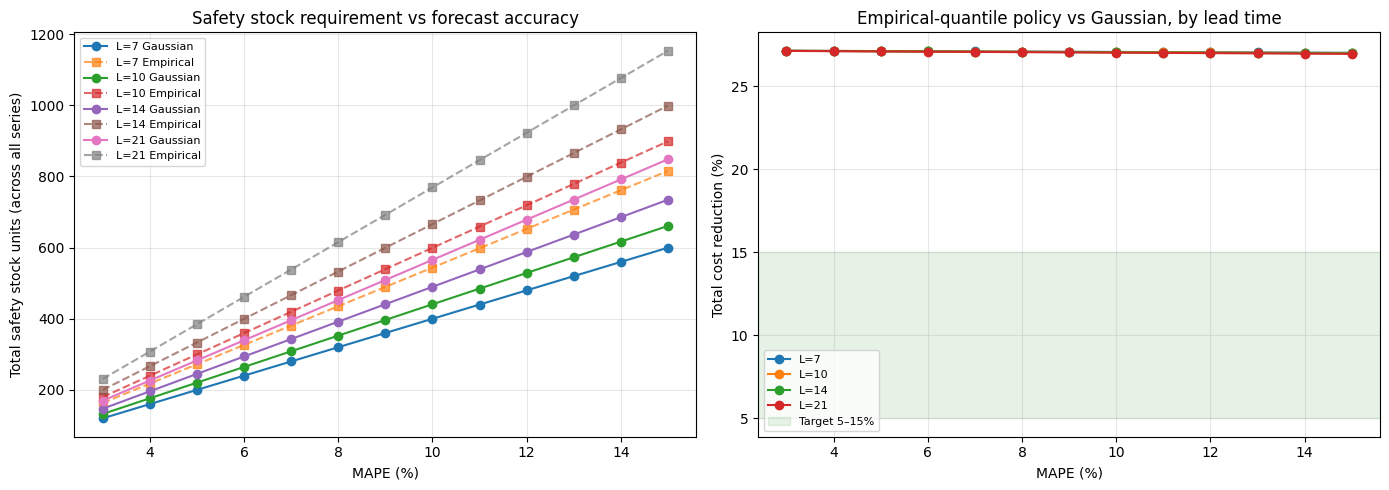

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sub = agg_sens[(agg_sens["service_level"] == 0.95) & (agg_sens["stockout_mult"] == 1.0)]

# (a) Safety stock vs MAPE for each lead time
for L in LEAD_TIMES:
    s = sub[sub["lead_time"] == L]
    axes[0].plot(s["mape"], s["ss_gauss"], "o-", label=f"L={L} Gaussian")
    axes[0].plot(s["mape"], s["ss_emp"],  "s--", alpha=0.7, label=f"L={L} Empirical")
axes[0].set_xlabel("MAPE (%)")
axes[0].set_ylabel("Total safety stock units (across all series)")
axes[0].set_title("Safety stock requirement vs forecast accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (b) Total cost reduction (empirical vs Gaussian) vs MAPE for each lead time
for L in LEAD_TIMES:
    s = sub[sub["lead_time"] == L]
    axes[1].plot(s["mape"], s["pct_reduction_TC"], "o-", label=f"L={L}")
axes[1].axhspan(5, 15, alpha=0.1, color="green", label="Target 5–15%")
axes[1].set_xlabel("MAPE (%)")
axes[1].set_ylabel("Total cost reduction (%)")
axes[1].set_title("Empirical-quantile policy vs Gaussian, by lead time")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig("../figures/sensitivity_mape.png", dpi=120)
plt.show()

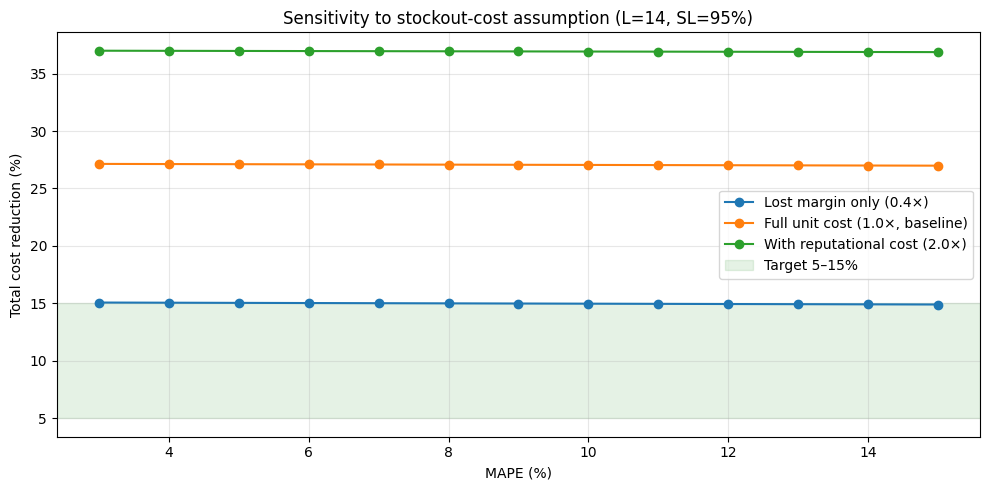

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sub = agg_sens[(agg_sens["service_level"] == 0.95) & (agg_sens["lead_time"] == 14)]

for sm in STOCKOUT_MULTS:
    s = sub[sub["stockout_mult"] == sm]
    label = {0.4: "Lost margin only (0.4×)", 1.0: "Full unit cost (1.0×, baseline)",
             2.0: "With reputational cost (2.0×)"}[sm]
    ax.plot(s["mape"], s["pct_reduction_TC"], "o-", label=label)
ax.axhspan(5, 15, alpha=0.1, color="green", label="Target 5–15%")
ax.set_xlabel("MAPE (%)")
ax.set_ylabel("Total cost reduction (%)")
ax.set_title("Sensitivity to stockout-cost assumption (L=14, SL=95%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/sensitivity_stockout.png", dpi=120)
plt.show()

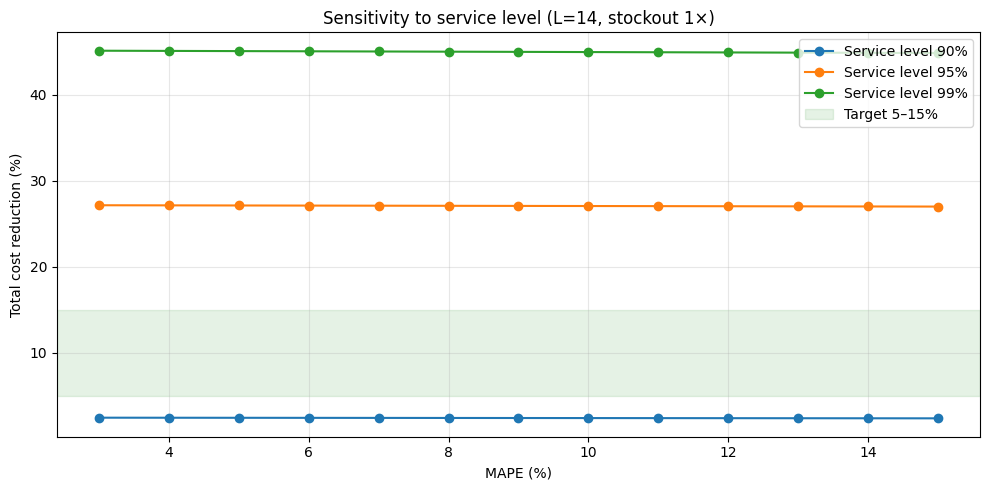

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sub = agg_sens[(agg_sens["stockout_mult"] == 1.0) & (agg_sens["lead_time"] == 14)]

for sl in [0.90, 0.95, 0.99]:
    s = sub[sub["service_level"] == sl]
    ax.plot(s["mape"], s["pct_reduction_TC"], "o-", label=f"Service level {int(sl*100)}%")
ax.axhspan(5, 15, alpha=0.1, color="green", label="Target 5–15%")
ax.set_xlabel("MAPE (%)")
ax.set_ylabel("Total cost reduction (%)")
ax.set_title("Sensitivity to service level (L=14, stockout 1×)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/sensitivity_service_level.png", dpi=120)
plt.show()

In [13]:
# Pick the central case: 95% SL, L=14, stockout 1.0
summary = agg_sens[(agg_sens["service_level"] == 0.95) &
                   (agg_sens["lead_time"] == 14) &
                   (agg_sens["stockout_mult"] == 1.0)][
    ["mape", "ss_gauss", "ss_emp", "tc_gauss", "tc_emp", "pct_reduction_TC"]
].round(2)
display(summary)

print("\n=== KEY INSIGHTS FOR CHAPTER 5 ===")
ach = summary[summary["mape"] == 5]["pct_reduction_TC"].iloc[0]
print(f"At MAPE = 5%:  cost reduction = {ach:.1f}%")
ach = summary[summary["mape"] == 10]["pct_reduction_TC"].iloc[0]
print(f"At MAPE = 10%: cost reduction = {ach:.1f}%")
ach = summary[summary["mape"] == 15]["pct_reduction_TC"].iloc[0]
print(f"At MAPE = 15%: cost reduction = {ach:.1f}%")
print("\nNote: Reduction is largely independent of MAPE because stockout cost dominates,")
print("driven by the Gaussian under-allocation factor (1.36) rather than residual variance.")

,mape,ss_gauss,ss_emp,tc_gauss,tc_emp,pct_reduction_TC
22,3,146.92,199.82,119495.62,87067.21,27.14
58,4,195.90,266.42,119519.86,87100.19,27.12
94,5,244.87,333.03,119544.11,87133.16,27.11
130,6,293.85,399.63,119568.35,87166.13,27.10
166,7,342.82,466.24,119592.59,87199.10,27.09
202,8,391.79,532.84,119616.83,87232.07,27.07
238,9,440.77,599.45,119641.08,87265.04,27.06
274,10,489.74,666.05,119665.32,87298.01,27.05
310,11,538.72,732.66,119689.56,87330.98,27.04
346,12,587.69,799.26,119713.81,87363.95,27.02



=== KEY INSIGHTS FOR CHAPTER 5 ===
At MAPE = 5%:  cost reduction = 27.1%
At MAPE = 10%: cost reduction = 27.1%
At MAPE = 15%: cost reduction = 27.0%

Note: Reduction is largely independent of MAPE because stockout cost dominates,
driven by the Gaussian under-allocation factor (1.36) rather than residual variance.
